# Predictive closure analysis

Human-facing view of the three predictive-closure cells. Implementations live in `src/experiments/`; the CLI is `python experiments/run.py <command>`.

| Cell | Command | GPU? |
|---|---|---|
| Table 2 / Cor. 2 check | `python experiments/run.py table2` | no |
| Tabular sampling (uniform vs family) | `python experiments/run.py tabular-sampling` | no |
| Transformer law (confirm) | `python experiments/run.py transformer-law --config configs/experiments/closure_transformer_law_confirm.yaml --confirm --device cuda:2` | yes |

YAML paths are unchanged. Do not treat kernel files or construction `oracle_slot=1` as mechanistic closure of a trained net. Full copy-paste: `results/closure_handcoded/RUN_TRANSFORMER.md`.

In [1]:
import json
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
OUT = ROOT / "results" / "closure_handcoded"
print("root", ROOT)

root /home/hariguru/aayus/trace


## Table 2 verdict (CPU)

Pre-registered $\varepsilon=1/2$: outcome should stay above chance at $D=2,4$, collapse from $D=6$, sit at $1/K$ at $D=8$; process stays high. Writes `table2_prediction.json` then checks `results/mechanism_deep/recovered.csv`.

In [2]:
from src.experiments.closure_table2 import main as table2_main

rc = table2_main([])
verdict = json.loads((OUT / "table2_verdict.json").read_text())
v = verdict["verdict"]
print("overall", v["overall"], f"{v['n_passed']}/{v['n_checks']}")
print(json.dumps(v["empirical"], indent=2))
assert v["overall"] == "MATCH", v

=== pre-registered prediction (ε=1/2, before Table 2) ===
  D=2  ε^1=0.50000  vs 1/K=0.0625  → succeed
  D=4  ε^3=0.12500  vs 1/K=0.0625  → succeed
  D=6  ε^5=0.03125  vs 1/K=0.0625  → collapse
  D=8  ε^7=0.00781  vs 1/K=0.0625  → collapse
wrote /home/hariguru/aayus/trace/results/closure_handcoded/table2_prediction.json
=== check against recovered Table 2 ===
  process_all_high: True
  outcome_D2_succeed: True
  outcome_D4_succeed: True
  outcome_D6_collapse: True
  outcome_D8_chance: True
  monotone: True
  n_passed: 6
  n_checks: 6
  overall: MATCH
  empirical: {'D2_outcome': 0.9727, 'D2_outcome_local': 0.9875, 'D2_process': 1.0, 'D4_outcome': 0.7211, 'D4_outcome_local': 0.875, 'D4_process': 1.0, 'D6_outcome': 0.1281, 'D6_outcome_local': 0.5563, 'D6_process': 1.0, 'D8_outcome': 0.0625, 'D8_outcome_local': 0.2031, 'D8_process': 1.0}
wrote /home/hariguru/aayus/trace/results/closure_handcoded/table2_verdict.json
overall MATCH 6/6
{
  "D2_outcome": 0.9727,
  "D2_outcome_local": 0.9875,
 

## Tabular sampling (CPU)

App. I samples 52 gate strings uniformly; Transformer sweeps sample a family first. Same $\rho$ grid, both laws. Load the already-run paper-$N$ frontiers; rerun with `--quick` only if you need plumbing.

,sampling,symmetric_rho50,coherent_rho50,order_coh_minus_sym,symmetric_at_0.25,coherent_at_0.25
0,uniform,0.25,0.6,0.35,1.0,0.057
1,family,0.25,0.6,0.35,1.0,0.063


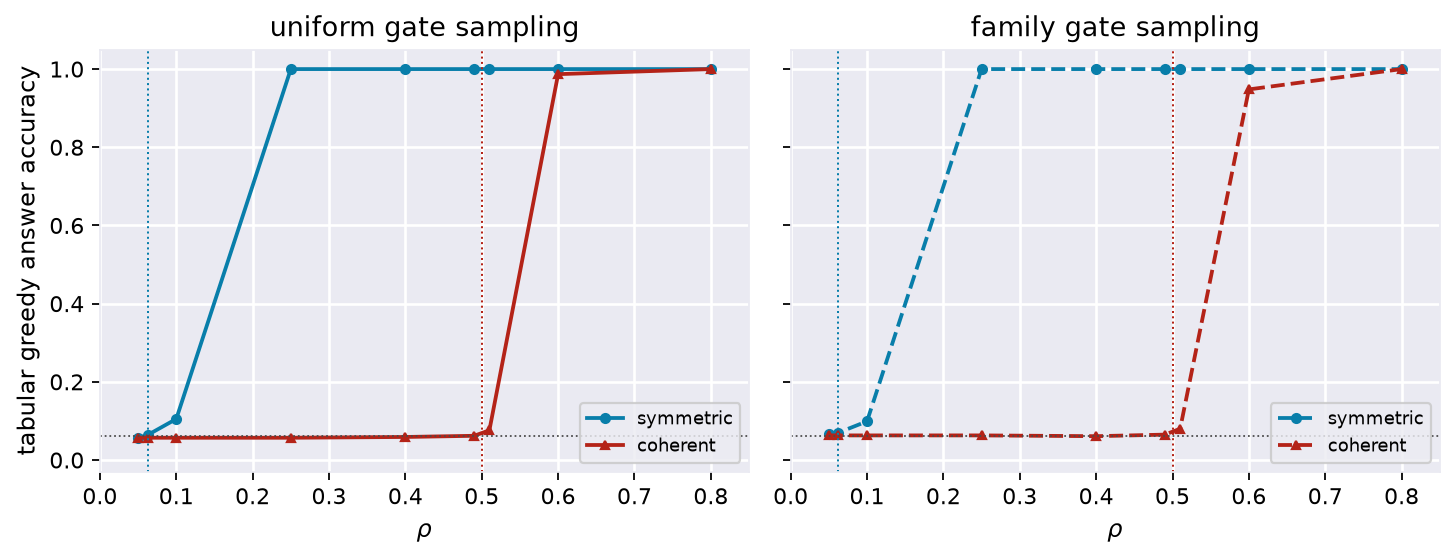

In [3]:
import pandas as pd

frontiers = OUT / "tabular_sampling" / "frontiers.csv"
if frontiers.exists():
    frame = pd.read_csv(frontiers)
else:
    from src.experiments.closure_tabular_sampling import main as sampling_main
    sampling_main(["--quick"])
    frame = pd.read_csv(frontiers)
display(frame)
png = OUT / "tabular_sampling" / "frontiers.png"
if png.exists():
    from IPython.display import Image, display as show
    show(Image(filename=str(png)))

## Transformer law — how to launch (you run GPU)

Self-check is CPU and cheap. Smoke/confirm need a GPU; invoke as `python experiments/run.py ...`, not as an executable. Confirm YAML is still `configs/experiments/closure_transformer_law_confirm.yaml`.

In [4]:
from src.experiments.closure_transformer_law import main as law_main

print("=== self-check (CPU) ===")
law_main(["--self-check"])
print()
print("# smoke (minutes, one GPU; plumbing only)")
print("python experiments/run.py transformer-law \\")
print("  --config configs/experiments/closure_transformer_law_smoke.yaml \\")
print("  --device cuda:2")
print()
print("# confirm — the one GPU job if budget is one")
print("python experiments/run.py transformer-law \\")
print("  --config configs/experiments/closure_transformer_law_confirm.yaml \\")
print("  --confirm --device cuda:2")

=== self-check (CPU) ===
[self-check] tabular ρ=0.25  sym=58.75%  coh=4.75%
[self-check] mix-pool gold preserved; ρ=0 state agreement=0.000
wrote /home/hariguru/aayus/trace/results/closure_handcoded/transformer_law/self_check.json

# smoke (minutes, one GPU; plumbing only)
python experiments/run.py transformer-law \
  --config configs/experiments/closure_transformer_law_smoke.yaml \
  --device cuda:2

# confirm — the one GPU job if budget is one
python experiments/run.py transformer-law \
  --config configs/experiments/closure_transformer_law_confirm.yaml \
  --confirm --device cuda:2


/home/hariguru/aayus/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Existing confirm artifacts, if present. Decision is directional SHIFT vs no-split NEGATIVE; landing away from $0.5$ is not a failure if the curves split.

decision SHIFT
{
  "probe_rho": 0.25,
  "symmetric_minus_coherent_at_0.25": -0.05859375,
  "frontier_rho50_symmetric": 0.4,
  "frontier_rho50_coherent": 0.51,
  "frontier_order_coh_minus_sym": 0.10999999999999999,
  "shift_if": "DIRECTIONAL: at \u03c1=0.25, symmetric\u2212coherent \u2265 0.15, or \u03c1_50(coherent)\u2212\u03c1_50(symmetric) \u2265 0.1. Do not require \u03c1_50 \u2248 1/K or 1/2. Offset toward ~0.85 is expected (D.10).",
  "negative_if": "no split: |\u0394acc| at \u03c1=0.25 < 0.1 and |\u0394\u03c1_50| < 0.1 (both curves sit together, typically near ~0.85)",
  "not_a_failure": "landing away from 0.5 / 0.0625 is not NEGATIVE if the curves split",
  "decision": "SHIFT"
}


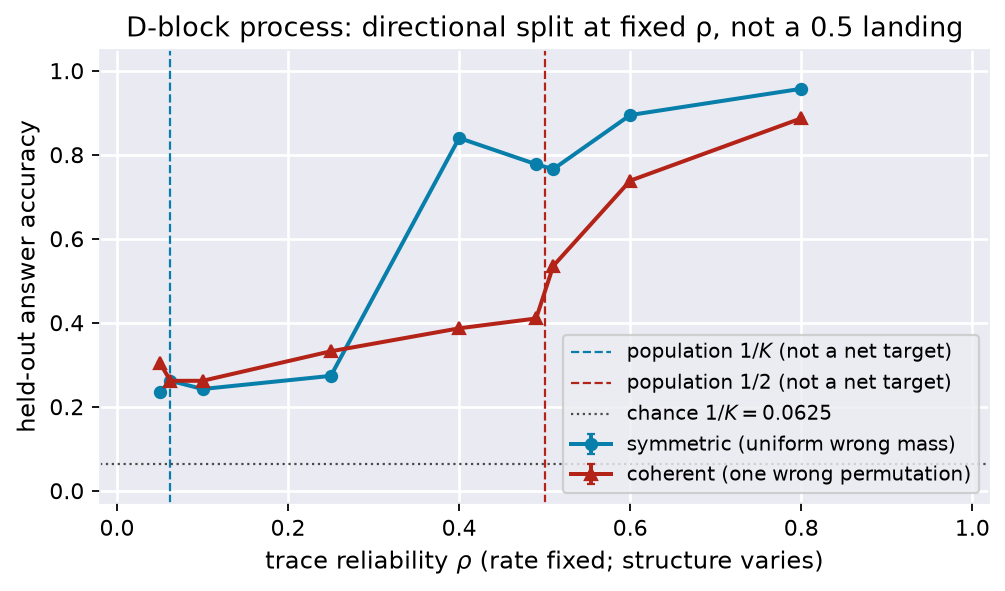

In [5]:
confirm = OUT / "transformer_law" / "confirm" / "persist.json"
if confirm.exists():
    persist = json.loads(confirm.read_text())
    print("decision", persist["verdict"]["decision"])
    print(json.dumps(persist["verdict"], indent=2))
    fig = OUT / "transformer_law" / "confirm" / "accuracy.png"
    if fig.exists():
        from IPython.display import Image, display as show
        show(Image(filename=str(fig)))
else:
    print("no confirm persist.json yet — run the GPU command above")

## Other first-class commands

Same CLI, implementations in `src/experiments/`:

```bash
python experiments/run.py --help
python experiments/run.py kernel
python experiments/run.py handcoded --device cpu
python experiments/run.py noise-threshold
python experiments/run.py recover-mechanism-deep
python experiments/run.py build-executor-results --input results/executor_comparison/depth_replication --paper Paper
```

Training jobs that already have `python -m src <command>` stay there (`reliability`, `outcome-local`, `executor`, …).